In [2]:
import tarfile
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import Counter
from fairchem.core.datasets import AseDBDataset
import numpy as np
from scipy import stats

os.chdir('../..')

from utils.load_datasets import MaterialsProject

/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
W0203 15:25:43.255000 45333 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [3]:
mp = MaterialsProject()
df = mp.load_data()
mp.get_summary()

2026-02-03 15:25:43.452 | INFO     | utils.load_datasets:load_data:134 - Detected primary dataset length: 133420
2026-02-03 15:25:43.452 | DEBUG    | utils.load_datasets:load_data:143 - Skipping batch_atoms: Length 3880497 != 133420
2026-02-03 15:25:43.453 | DEBUG    | utils.load_datasets:load_data:143 - Skipping batch_edges: Length 0 != 133420
2026-02-03 15:25:43.453 | DEBUG    | utils.load_datasets:load_data:143 - Skipping cell: Length 133420 != 133420
2026-02-03 15:25:43.458 | DEBUG    | utils.load_datasets:load_data:143 - Skipping num_structures: Length 1 != 133420
2026-02-03 15:25:43.459 | DEBUG    | utils.load_datasets:load_data:143 - Skipping pos: Length 3880497 != 133420
2026-02-03 15:25:43.459 | DEBUG    | utils.load_datasets:load_data:143 - Skipping z: Length 3880497 != 133420
2026-02-03 15:25:43.460 | INFO     | utils.load_datasets:load_data:146 - Successfully loaded 6 columns.



--- Loaded 133420 Materials ---
<class 'pandas.DataFrame'>
RangeIndex: 133420 entries, 0 to 133419
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   energy_above_hull  129622 non-null  float32
 1   energy_pa          133420 non-null  float32
 2   material_id        133420 non-null  int64  
 3   num_atoms          133420 non-null  int64  
 4   num_edges          133420 non-null  int64  
 5   periodic           133420 non-null  bool   
dtypes: bool(1), float32(2), int64(3)
memory usage: 4.2 MB
None


In [4]:
df

,energy_above_hull,energy_pa,material_id,num_atoms,num_edges,periodic
0,0.000000,-0.244888,1103373,12,0,True
1,0.020108,-0.462910,1106279,16,0,True
2,0.052628,-1.715086,1224519,44,0,True
3,0.632605,-1.316445,1204424,64,0,True
4,0.022857,-0.535822,1226074,12,0,True
...,...,...,...,...,...,...
133415,0.144329,-0.149223,30554,8,0,True
133416,0.006975,-3.496491,556284,14,0,True
133417,0.009295,-0.136749,30499,26,0,True
133418,0.004507,-0.366980,22437,38,0,True


In [10]:
print(max(df['num_edges']))

0


Stats:
- Materials at Ground State (Hull=0): 33608
- High Energy Outliers (>0.5 eV): 9464
- Average Coordination (Edges/Atom): 0.00


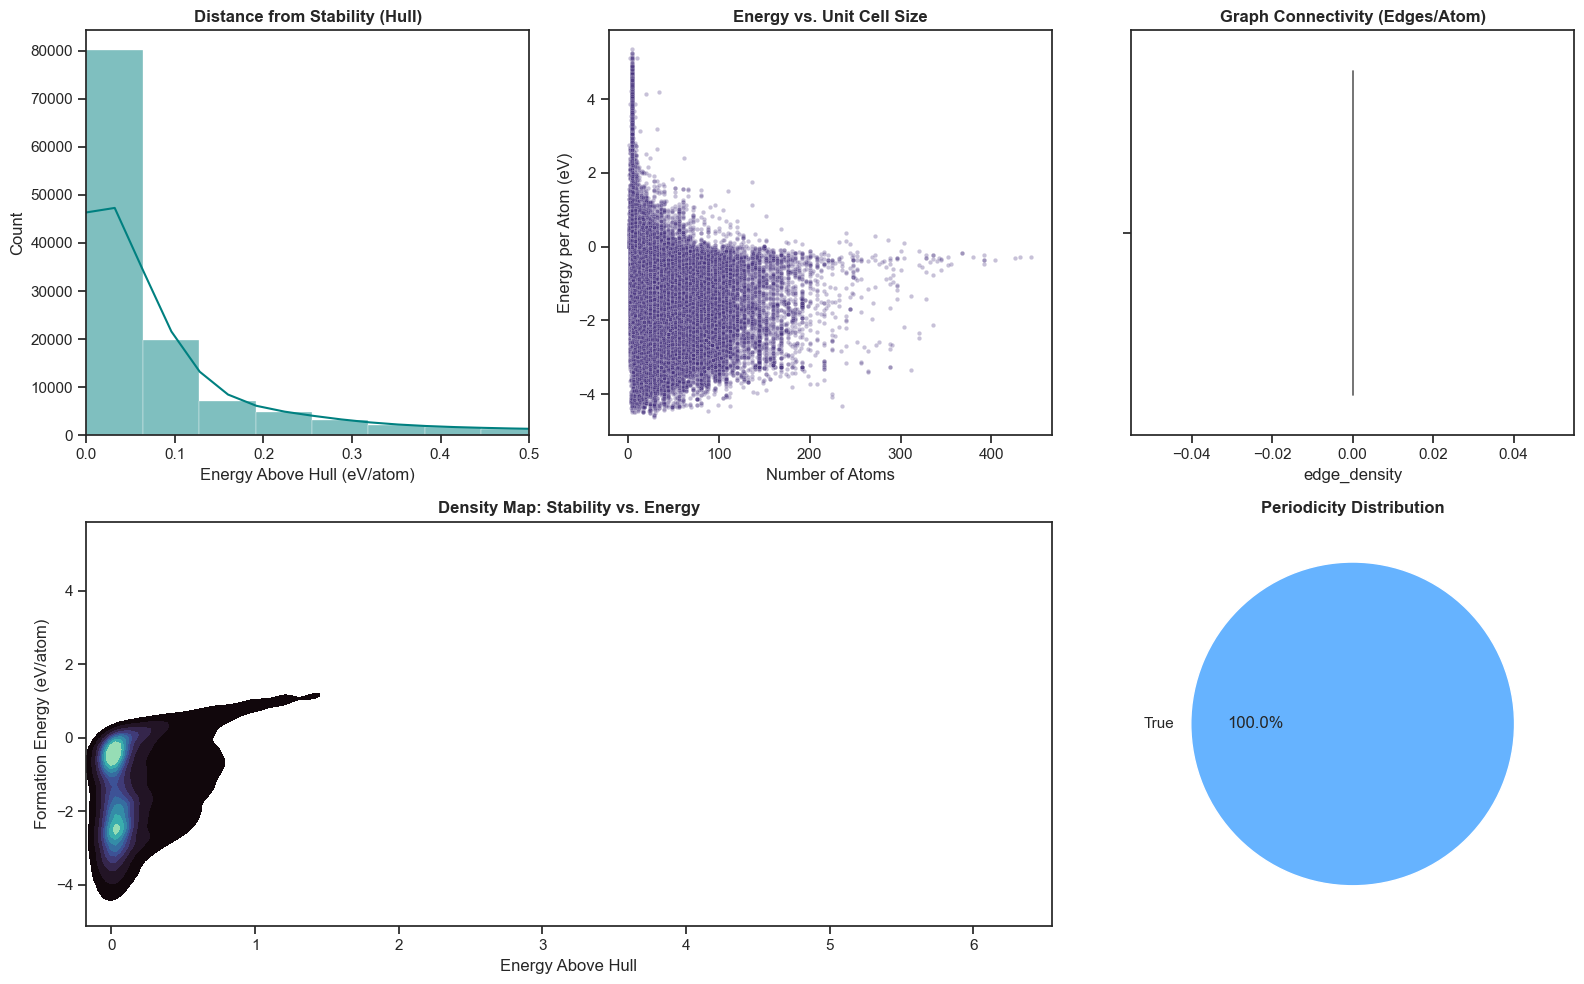

In [5]:

def plot_materials_analysis(df):
    # Set style for professional research plotting
    sns.set_theme(style="ticks", palette="viridis")
    fig = plt.figure(figsize=(16, 10))
    spec = fig.add_gridspec(2, 3)

    # --- 1. Stability Distribution (Energy Above Hull) ---
    # Highlights how many materials are at the 'Ground State' (0.0)
    ax1 = fig.add_subplot(spec[0, 0])
    sns.histplot(df['energy_above_hull'].dropna(), bins=100, kde=True, ax=ax1, color='teal')
    ax1.set_title("Distance from Stability (Hull)", fontweight='bold')
    ax1.set_xlabel("Energy Above Hull (eV/atom)")
    ax1.set_xlim(0, 0.5) # Focus on the most relevant physical range

    # --- 2. Phase Space: Energy vs. Complexity ---
    # Detects structural outliers
    ax2 = fig.add_subplot(spec[0, 1])
    sns.scatterplot(data=df, x='num_atoms', y='energy_pa', alpha=0.3, s=10, ax=ax2)
    ax2.set_title("Energy vs. Unit Cell Size", fontweight='bold')
    ax2.set_xlabel("Number of Atoms")
    ax2.set_ylabel("Energy per Atom (eV)")

    # --- 3. Connectivity Density ---
    # Creates a new feature: edges per atom to find coordination anomalies
    df['edge_density'] = df['num_edges'] / df['num_atoms']
    ax3 = fig.add_subplot(spec[0, 2])
    sns.violinplot(x=df['edge_density'], ax=ax3, color='orchid')
    ax3.set_title("Graph Connectivity (Edges/Atom)", fontweight='bold')

    # --- 4. Anomaly Heatmap (Joint Distribution) ---
    # Shows where the "Normal" materials live; outliers are in the empty space
    ax4 = fig.add_subplot(spec[1, :2])
    sns.kdeplot(data=df, x='energy_above_hull', y='energy_pa', 
                fill=True, thresh=0.05, levels=10, cmap="mako", ax=ax4)
    ax4.set_title("Density Map: Stability vs. Energy", fontweight='bold')
    ax4.set_xlabel("Energy Above Hull")
    ax4.set_ylabel("Formation Energy (eV/atom)")

    # --- 5. Periodicity Check ---
    # Pie chart for periodic vs non-periodic (usually 100% True in MP)
    ax5 = fig.add_subplot(spec[1, 2])
    df['periodic'].value_counts().plot.pie(autopct='%1.1f%%', ax=ax5, colors=['#66b3ff','#99ff99'])
    ax5.set_title("Periodicity Distribution", fontweight='bold')
    ax5.set_ylabel("")

    plt.tight_layout()
    plt.show()

# Execution
print("Stats:")
print(f"- Materials at Ground State (Hull=0): {(df['energy_above_hull'] == 0).sum()}")
print(f"- High Energy Outliers (>0.5 eV): {(df['energy_above_hull'] > 0.5).sum()}")
print(f"- Average Coordination (Edges/Atom): {(df['num_edges'] / df['num_atoms']).mean():.2f}")

plot_materials_analysis(df)

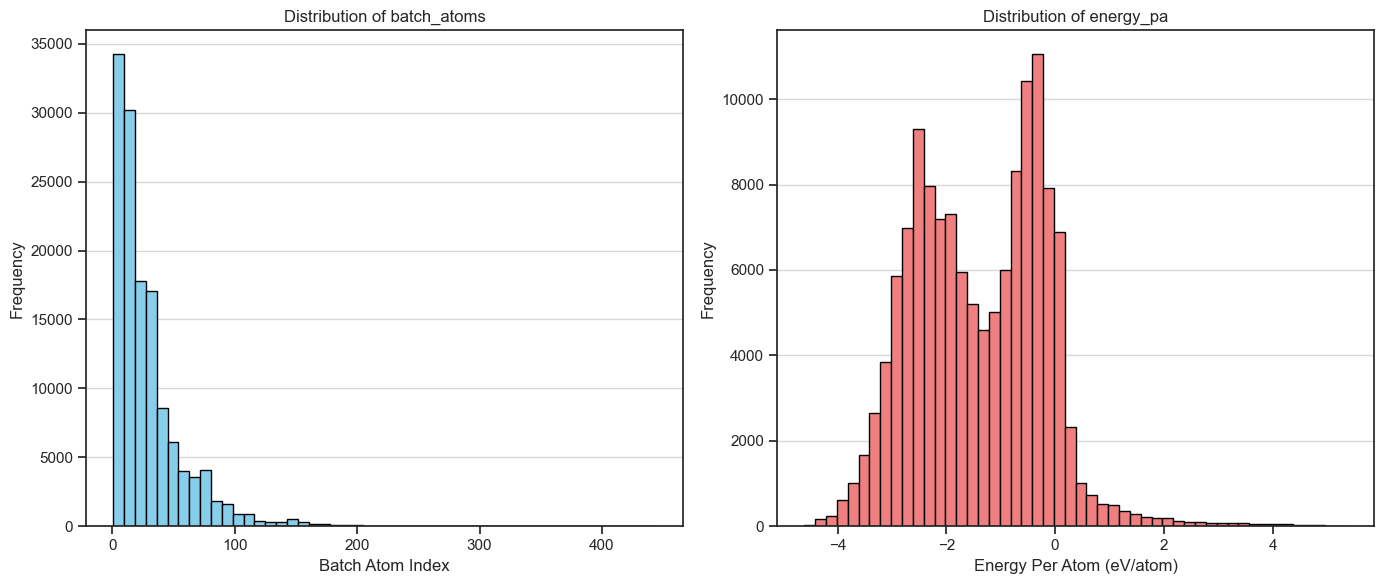

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Histogram for 'batch_atoms'
axes[0].hist(df['num_atoms'], bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('Distribution of batch_atoms')
axes[0].set_xlabel('Batch Atom Index')
axes[0].set_ylabel('Frequency')
axes[0].grid(axis='y', alpha=0.75)

# Histogram for 'energy_pa'
axes[1].hist(df['energy_pa'], bins=50, color='lightcoral', edgecolor='black')
axes[1].set_title('Distribution of energy_pa')
axes[1].set_xlabel('Energy Per Atom (eV/atom)')
axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y', alpha=0.75)

plt.tight_layout()
plt.show()
